1. Import and setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
import time
from xrfm import xRFM
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import torch
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from itertools import product
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from xgboost import plot_importance
from xrfm.tree_utils import get_param_tree
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Prevent output being printed out
import os
import sys
from contextlib import redirect_stdout

from ucimlrepo import fetch_ucirepo

d:\miniconda3\envs\AI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [11]:
# Columns of the dataset
columns = X.columns

print(f"Dataset shape: {X.shape}")
print(f"Target shape: {y.shape}\n")

# Fill "?" value into NaN
X.replace(["?"], np.nan, inplace=True)
print(f"Missing values:\n{X.isnull().sum()}")

# Covert char_freq_[ to char_freq_bracket
X.columns = X.columns.str.replace("[", "bracket", regex=False)
X.head()

Dataset shape: (4601, 57)
Target shape: (4601, 1)

Missing values:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_bracket,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.111546,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.111546,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222


In [12]:
SEED = 48

# Standardize the numerical value
scaler = StandardScaler()
X[columns] = scaler.fit_transform(X[columns])
print("Standardize the numerical value")
print("Sample of scaled data")
print(X[columns].head())

# Splitting of data
# Training = 80%, validation = 10%, test = 10%
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.5, stratify=y_val, random_state=SEED
)

print()
print(f"Training size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

Standardize the numerical value
Sample of scaled data
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0       -0.342434           0.330885       0.712859       -0.0469   
1        0.345359           0.051909       0.435130       -0.0469   
2       -0.145921          -0.165072       0.851723       -0.0469   
3       -0.342434          -0.165072      -0.556761       -0.0469   
4       -0.342434          -0.165072      -0.556761       -0.0469   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0       0.011565       -0.350266         -0.291794           -0.262562   
1      -0.256117        0.672399          0.244743           -0.088010   
2       1.364846        0.343685          0.193644            0.036670   
3       0.472573       -0.350266          0.500237            1.308402   
4       0.472573       -0.350266          0.500237            1.308402   

   word_freq_order  word_freq_mail  ...  word_freq_conference  char_freq_;  \
0       

In [13]:
# Create xRFM Wrapper for GridSearchCV

# Create log uniform distribution
def loguniform(low, high, size):
    log_low = np.log10(low)
    log_high = np.log10(high)
    
    sample_log = np.random.uniform(log_low, log_high, size=size)
    
    samples = 10 ** sample_log
    
    return samples

# Generate rfm_params distribution
def generate_rfm_params(size):
    bandwidths = loguniform(1, 200, size)
    bandwidth_modes = ["constant", "adaptive"]
    diagonals = [False, True]
    exponents = np.random.uniform(0.7, 1.4, size=size)  
    regularisations = loguniform(1e-6, 1, size=size)
    
    rfm_params_list = []
    
    for bandwidth, mode, diag, exp, reg in list(product(bandwidths, bandwidth_modes, diagonals, exponents, regularisations)):
        kernel = None
        p = np.random.uniform(0, 1)
        norm_p = None
        if p > 0.2:
            kernel = "lpq_kermac"
            norm_p = np.random.uniform(exp, exp + 0.8 * (2 - exp))
        else:
            kernel = "laplace"
        
        rfm_params_list.append(
            {
                "model": {
                    "kernel": kernel,
                    "bandwidth": bandwidth,
                    "exponent": exp,
                    "norm_p": norm_p,
                    "diag": diag,
                    "bandwidth_mode": mode
                },
                "fit": {
                    "reg": reg,
                    "iters": 1,
                    "early_stop_rfm": True,
                    "M_batch_size": 500,
                    "verbose": True
                }
            }
        )
    return rfm_params_list

class xRFMWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, device, rfm_params=None):
        self.rfm_params = rfm_params
        self.device = device
        self.random_state = 48
        self.model = None
    
    @staticmethod
    def convert_df_to_numpy(X):
        return X.to_numpy().astype(np.float32)
    
    def fit(self, X, y):
        # Convert the shape of y
        X = self.convert_df_to_numpy(X)
        y = self.convert_df_to_numpy(y)
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)
    
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=self.random_state
        )
        self.model = xRFM(
            rfm_params=self.rfm_params,
            random_state=SEED,
            device=self.device,
            tuning_metric="accuracy",
            split_method='top_vector_agop_on_subset',
            min_subset_size=10000
        )
        with open(os.devnull, 'w') as f:
            with redirect_stdout(f):
                self.model.fit(X_train, y_train, X_val, y_val)
        return self
    
    def predict(self, X):
        X = self.convert_df_to_numpy(X)
        return self.model.predict(X)

    def predict_proba(self, X):
        X = self.convert_df_to_numpy(X)
        return self.model.predict_proba(X)

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = {
    "xRFM": (
        xRFMWrapper(device),
        { "rfm_params": generate_rfm_params(10) }
    ),
    "xGBoost": (
        XGBClassifier(objective="binary:logistic", random_state=SEED, device=str(device)),
        {
            "max_depth": np.arange(2, 15, 1),
            "learning_rate": np.linspace(0.01, 2, 50),
            "n_estimators": [5, 100, 50]
        }
    ),
    "MLP": (
        MLPClassifier(random_state=SEED, early_stopping=True, max_iter=500),
        {
            "hidden_layer_sizes": [(50,), (50, 50), (100,)],
            "activation": ["relu", "tanh"],
            "solver": ["sgd", "adam"],
            "alpha": np.linspace(0.001, 2, 10),
            "batch_size": np.arange(200, 600, 10),
            "learning_rate": ["constant", "adaptive"],
            "learning_rate_init": np.linspace(0.001, 1, 10)
        }
    )
}

In [16]:
result = {}

for name, (model, params) in best_model.items():
    print(f"Tuning and training {name} model")
    cv = StratifiedKFold(n_splits=5)
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        cv=cv,
        n_iter=200,
        scoring="accuracy",
        verbose=True
    )
    search.fit(X_val, y_val)
    
    best_param = search.best_params_
    model = model.set_params(**best_param)
    
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    
    result[name] = (model, end - start, best_param)
    print(f"Finish training {name} model")

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Tuning and training xRFM model
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
None
Using hard routing for tree prediction
None
Using hard routing for tree prediction
None
Using hard routing for tree prediction
None
Using hard routing for tree prediction
None
Using hard routing for tree prediction
None


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using hard routing for tree prediction
None
Using hard routing for tree prediction
None


...

Using hard routing for tree prediction
None


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

None


Building trees:   0%|          | 0/1 [00:21<?, ?it/s]


Finish training xRFM model
Tuning and training xGBoost model
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Finish training xGBoost model
Tuning and training MLP model
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Finish training MLP model


In [17]:
# Display the accuracy, auc, training, inference time
statistic = {
    "Models": [],
    "Accuracy": [],
    "ROC-AUC": [],
    "Training Time": [],
    "Inference Time": [],
}
for name, (model, training_t, best_param) in result.items():
    print(f"Best param of {name} model")
    print(f"{best_param}")
    print()
    
    start = time.time()
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    end = time.time()
    fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
    auc_score = auc(fpr, tpr)
    
    statistic["Models"].append(name)
    statistic["Accuracy"].append(accuracy_score(y_test, y_pred))
    statistic["Inference Time"].append(end - start)
    statistic["Training Time"].append(training_t)
    statistic["ROC-AUC"].append(auc_score)
    
result_df = pd.DataFrame(statistic)
print("Saving result table....")
result_df.to_csv("Basic_Statistic_Btw_Models.csv", index=False)
display(result_df)

Best param of xRFM model
{'rfm_params': {'model': {'kernel': 'lpq_kermac', 'bandwidth': np.float64(5.66863018628243), 'exponent': np.float64(0.70412195258842), 'norm_p': 0.8242861921293949, 'diag': True, 'bandwidth_mode': 'constant'}, 'fit': {'reg': np.float64(0.0002457621888642694), 'iters': 1, 'early_stop_rfm': True, 'M_batch_size': 500, 'verbose': True}}}

Using hard routing for tree prediction
Using hard routing for tree prediction
Best param of xGBoost model
{'n_estimators': 50, 'max_depth': np.int64(14), 'learning_rate': np.float64(0.09122448979591836)}

Best param of MLP model
{'solver': 'sgd', 'learning_rate_init': np.float64(0.889), 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50,), 'batch_size': np.int64(280), 'alpha': np.float64(0.44522222222222224), 'activation': 'relu'}

Saving result table....


,Models,Accuracy,ROC-AUC,Training Time,Inference Time
0,xRFM,0.963124,0.987888,21.537995,0.539053
1,xGBoost,0.956616,0.985958,0.995191,0.014610
2,MLP,0.917570,0.975757,0.920729,0.015164


Using hard routing for tree prediction


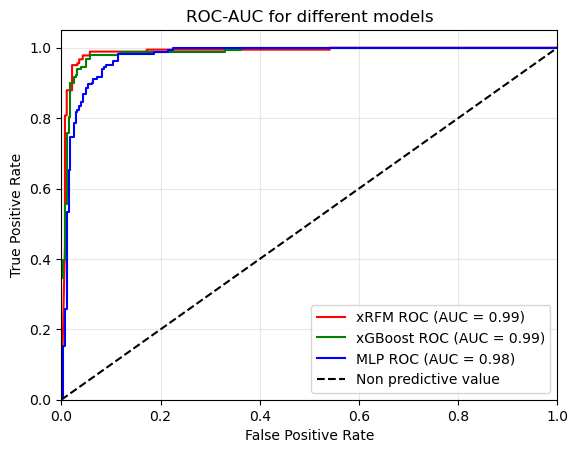

In [18]:
# Display the AUC-ROC graph
xrfm = result["xRFM"][0]
xgb = result["xGBoost"][0]
mlp = result["MLP"][0]
def plot_roc_graph(model, label, color, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=label + f" (AUC = {roc_auc:0.2f})", color=color)


plt.figure()
plt.title("ROC-AUC for different models")
plot_roc_graph(xrfm, "xRFM ROC", "red", X_test, y_test)
plot_roc_graph(xgb, "xGBoost ROC", "green", X_test, y_test)
plot_roc_graph(mlp, "MLP ROC", "blue", X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--', label='Non predictive value')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('ROC-AUC-plot.png', dpi=150, bbox_inches='tight')

RFM()


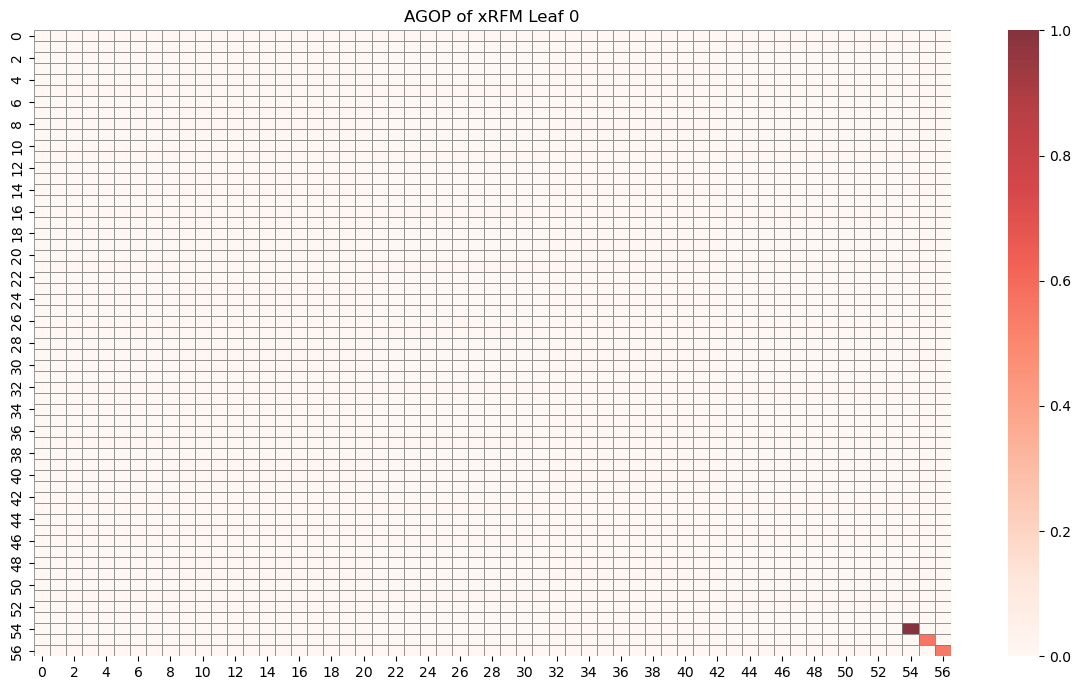

In [21]:
# Diplay AGOP matrix
def display_matrix(ax, matrix, color, leaf_count):
    if len(matrix.shape) == 1 or matrix.shape[1] == 1:
        matrix = torch.diag(matrix)

    sns.heatmap(
        matrix,
        cmap=color,
        linewidths=0.5,
        ax=ax,
        alpha=0.8,
        linecolor="grey"
    )
    ax.set_title(f"AGOP of xRFM Leaf {leaf_count}")

def get_leaf_matrix(param_tree, agops):
    if param_tree["type"] == "leaf":
        if param_tree["M"] == None:
            return
        agops.append(param_tree["M"])
        return
    
    get_leaf_matrix(param_tree["left"], agops)
    get_leaf_matrix(param_tree["right"], agops)
    
def get_agops(model):
    agops = []
    for t in model.trees:
        param_tree = get_param_tree(t, is_root=True)
        get_leaf_matrix(param_tree, agops)
    
    return agops

xrfm_model = xrfm.model
print(xrfm_model.trees[0]["model"])
agops = get_agops(xrfm_model)
num_leaf = len(agops)

if len(agops) != 0:
    fig, axes = plt.subplots(1, num_leaf, figsize=(7 * num_leaf + 5, 7))
    if len(agops) == 1:
        display_matrix(axes, agops[0], "Reds", 0)
    else:
        for i in range(num_leaf):
            display_matrix(axes[i], agops[i], "Reds", i)

    plt.savefig('Spambase_detection_AGOP.png', dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


In [ ]:
print(xrfm_model.trees[0]["model"])

None


In [23]:
# AGOP diag
agop = agops[0]
if len(agop.shape) == 1:
    agop_diag = agop
else:
    agop_diag = np.diag(agops[0])
agop_importance = pd.Series(agop_diag, index=X_test.columns, name=f"AGOP")
# PCA Loadings
# Fit PCA
print("Evaluate PCA loadings...\n")
pca = PCA()
pca.fit(X_test)

# Calculate loading
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(
    loadings, index=X_test.columns, columns=[f"PC{i + 1}" for i in range(len(X_test.columns))]
)

# Mutual Information Scores
print("Evaluate mutual information score...\n")
mi_scores = mutual_info_classif(X_test, y_test, random_state=48)
mi_series = pd.Series(mi_scores, index=X_test.columns, name="MI score")

# Permutation importance
print("Evaluate permutation important.....\n")
def get_permutation_importance(model, name, X, y):
    scorer = None
    if name == "xRFM":
        def xrfm_scorer(estimator, X_inp, y_inp):
            y_pred = estimator.predict(X_inp)
            return accuracy_score(y_pred, y_inp)
        
        scorer = xrfm_scorer
    else:
        scorer = "accuracy"
      
    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):  
            result = permutation_importance(
                model, X, y, scoring=scorer, n_repeats=5, random_state=SEED, n_jobs=1
            )

    perm_importance = pd.Series(result.importances_mean, index=X_test.columns, name=f"PI_{name}")
    return perm_importance

rfm_important = get_permutation_importance(xrfm, "xRFM", X_test, y_test)
xgb_important = get_permutation_importance(xgb, "XGBoost", X_test, y_test)
mlp_important = get_permutation_importance(mlp, "MLP", X_test, y_test)

Evaluate PCA loadings...

Evaluate mutual information score...

Evaluate permutation important.....



In [31]:
# xgb_important, rfm_important, mlp_important
comparision_df = pd.concat([agop_importance, mi_series, loadings_df, xgb_important, rfm_important, mlp_important], axis=1)
display_comparision_df = pd.concat([agop_importance, mi_series, loadings_df["PC1"], xgb_important, rfm_important, mlp_important], axis=1)

display_comparision_df = display_comparision_df.sort_values(by="AGOP", ascending=False)

comparision_df.to_csv("Spambase_feature_importance.csv", index=True)

display(display_comparision_df.head(15))

,AGOP,MI score,PC1,PI_XGBoost,PI_xRFM,PI_MLP
capital_run_length_average,1.000000,0.160434,-0.023964,0.009111,0.008243,4.440892e-17
capital_run_length_longest,0.560446,0.166593,-0.142612,0.016486,0.013015,0.000000e+00
capital_run_length_total,0.551788,0.138852,-0.134643,0.004338,0.008677,-2.169197e-03
word_freq_george,0.005348,0.141550,0.132024,0.022126,0.007809,1.822126e-02
char_freq_!,0.002448,0.229103,-0.131421,0.022126,0.010846,2.169197e-02
word_freq_hp,0.001896,0.164176,0.599761,0.036443,0.024729,2.863341e-02
word_freq_you,0.001754,0.075990,-0.336594,0.006074,0.003905,-2.603037e-03
char_freq_(,0.001699,0.028665,0.285251,0.000868,0.002603,2.220446e-17
word_freq_edu,0.001497,0.016049,0.036967,0.018221,0.007375,9.544469e-03
char_freq_$,0.001113,0.171564,-0.174738,0.019523,0.003905,1.561822e-02


<Figure size 640x480 with 0 Axes>

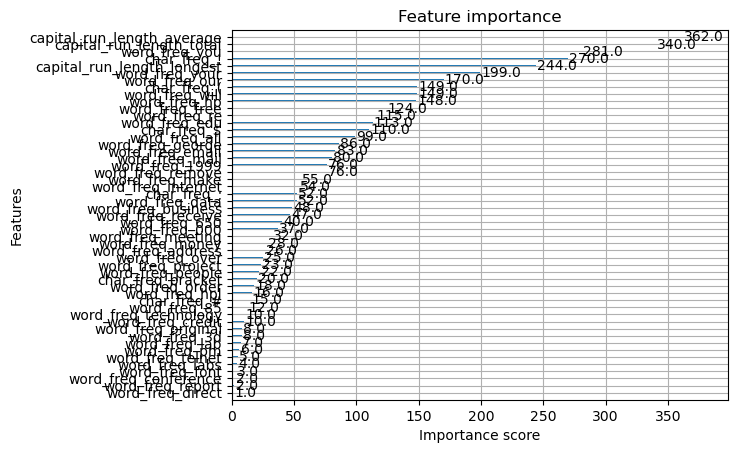

In [33]:
plt.figure()
plot_importance(xgb)
plt.savefig('xgb_plot_important.png', dpi=150, bbox_inches='tight')
plt.show()